# GameTheory-05-ZeroSum-Minimax

**Navigation** : [<< 4-NashEquilibrium](GameTheory-04-NashEquilibrium.ipynb) | [Index](README.md) | [6-EvolutionTrust >>](GameTheory-06-EvolutionTrust.ipynb)

## Jeux a Somme Nulle et Theoreme Minimax

Ce notebook explore les **jeux a somme nulle** et le celebre **theoreme minimax** de Von Neumann (1928).

### Objectifs d'apprentissage

1. Définir les jeux a somme nulle
2. Comprendre les stratégies maximin et minimax
3. Demontrer le theoreme minimax
4. Resoudre par programmation lineaire
5. Applications : Pierre-Feuille-Ciseaux, Blotto

### Prerequis

- Notebooks 1-4 : Fondations, jeux en forme normale, topologie, equilibres de Nash
- Notion de stratégie mixte et d'equilibre en stratégies mixtes
- Bases de la programmation lineaire (optionnel mais utile)

### Duree estimee : 40 minutes

### Theoreme Minimax (Von Neumann, 1928)
> Dans tout jeu a deux joueurs et somme nulle, il existe une valeur $v$ telle que :
> $$\max_{\sigma} \min_{\tau} u(\sigma, \tau) = \min_{\tau} \max_{\sigma} u(\sigma, \tau) = v$$

**Source primaire.** Le theoreme minimax (existence d'une valeur du jeu en stratégies mixtes pour tout jeu a somme nulle) est etabli par John von Neumann dans *Zur Théorie der Gesellschaftsspiele* (Mathematische Annalen 100:295-320, 1928 ; DOI 10.1007/BF01448847) -- l'acte de naissance de la théorie des jeux. L'equivalence avec la dualite forte de la programmation lineaire, utilisee pour la resolution numérique plus loin dans ce notebook, a ete demontree ulterieurement par Dantzig, von Neumann et Gale.

In [1]:
# Imports
import numpy as np
import nashpy as nash
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from typing import Tuple, Optional
import warnings
warnings.filterwarnings('ignore')
print("Imports OK : numpy, scipy.optimize")


Imports OK : numpy, scipy.optimize


## 1. Definition : Jeux a somme nulle

### Definition

Un jeu est a **somme nulle** si pour tout profil de stratégies $(s_1, s_2)$ :
$$u_1(s_1, s_2) + u_2(s_1, s_2) = 0$$

Equivalemment : $B = -A$ (les gains d'un joueur sont les pertes de l'autre).

### Exemples classiques
- Pierre-Feuille-Ciseaux
- Echecs, Dames, Go (victoire = +1, defaite = -1)
- Matching Pennies
- Colonel Blotto

In [2]:
class ZeroSumGame:
    """
    Jeu a somme nulle a deux joueurs.
    
    La matrice A represente les gains de Row.
    Les gains de Col sont -A.
    """
    
    def __init__(self, A: np.ndarray, 
                 row_labels: list = None,
                 col_labels: list = None,
                 name: str = "Zero-Sum Game"):
        self.A = np.array(A, dtype=float)
        self.m, self.n = self.A.shape
        self.name = name
        self.row_labels = row_labels or [f"R{i}" for i in range(self.m)]
        self.col_labels = col_labels or [f"C{j}" for j in range(self.n)]
    
    def payoff(self, sigma_row: np.ndarray, sigma_col: np.ndarray) -> float:
        """Gain de Row (= -gain de Col)."""
        return sigma_row @ self.A @ sigma_col
    
    def display(self):
        """Affiche la matrice des gains."""
        print(f"\n{self.name} (gains de Row)")
        print("=" * 50)
        
        # Header
        header = "        " + "  ".join(f"{c:>8}" for c in self.col_labels)
        print(header)
        print("-" * len(header))
        
        # Rows
        for i, label in enumerate(self.row_labels):
            row_str = f"{label:>6}  "
            row_str += "  ".join(f"{self.A[i,j]:>8.2f}" for j in range(self.n))
            print(row_str)

# Exemples de jeux a somme nulle

# Pierre-Feuille-Ciseaux
rps = ZeroSumGame(
    A=[[0, -1, 1],
       [1, 0, -1],
       [-1, 1, 0]],
    row_labels=['Pierre', 'Feuille', 'Ciseaux'],
    col_labels=['Pierre', 'Feuille', 'Ciseaux'],
    name="Pierre-Feuille-Ciseaux"
)
rps.display()

# Matching Pennies
mp = ZeroSumGame(
    A=[[1, -1],
       [-1, 1]],
    row_labels=['Pile', 'Face'],
    col_labels=['Pile', 'Face'],
    name="Matching Pennies"
)
mp.display()


Pierre-Feuille-Ciseaux (gains de Row)
          Pierre   Feuille   Ciseaux
------------------------------------
Pierre      0.00     -1.00      1.00
Feuille      1.00      0.00     -1.00
Ciseaux     -1.00      1.00      0.00

Matching Pennies (gains de Row)
            Pile      Face
--------------------------
  Pile      1.00     -1.00
  Face     -1.00      1.00


## 2. Stratégies Maximin et Minimax

### Stratégie Maximin (pour Row)

Row cherche a **maximiser** son gain minimum (pessimiste) :
$$\bar{v}_1 = \max_{\sigma} \min_{\tau} \sigma^T A \tau = \max_{\sigma} \min_j (A\sigma)_j$$

### Stratégie Minimax (pour Col)

Col cherche a **minimiser** le gain maximum de Row :
$$\underline{v}_2 = \min_{\tau} \max_{\sigma} \sigma^T A \tau = \min_{\tau} \max_i (A^T\tau)_i$$

### Inegalite fondamentale

Toujours : $\bar{v}_1 \leq \underline{v}_2$ (le pessimiste fait au moins aussi mal que l'optimiste).

In [3]:
def maximin_pure(game: ZeroSumGame) -> Tuple[int, float]:
    """
    Calcule la stratégie maximin pure de Row.
    
    Returns:
        (action, valeur maximin)
    """
    min_per_row = np.min(game.A, axis=1)  # Pire cas pour chaque action
    best_row = np.argmax(min_per_row)     # Meilleur pire cas
    return best_row, min_per_row[best_row]

def minimax_pure(game: ZeroSumGame) -> Tuple[int, float]:
    """
    Calcule la stratégie minimax pure de Col.
    
    Returns:
        (action, valeur minimax)
    """
    max_per_col = np.max(game.A, axis=0)  # Pire cas pour Col (meilleur pour Row)
    best_col = np.argmin(max_per_col)     # Minimise le max de Row
    return best_col, max_per_col[best_col]

def analyze_maximin_minimax(game: ZeroSumGame):
    """Analyse les stratégies maximin/minimax."""
    game.display()
    
    row_action, v_maximin = maximin_pure(game)
    col_action, v_minimax = minimax_pure(game)
    
    print(f"\nAnalyse maximin/minimax:")
    print("-" * 40)
    print(f"Maximin (Row): action '{game.row_labels[row_action]}', valeur = {v_maximin}")
    print(f"Minimax (Col): action '{game.col_labels[col_action]}', valeur = {v_minimax}")
    
    if abs(v_maximin - v_minimax) < 1e-10:
        print(f"\n=> Point-selle existe ! Valeur du jeu = {v_maximin}")
        print(f"   Equilibre: ({game.row_labels[row_action]}, {game.col_labels[col_action]})")
    else:
        print(f"\n=> Pas de point-selle en stratégies pures")
        print(f"   Gap: {v_minimax - v_maximin}")

# Analyser les jeux
analyze_maximin_minimax(mp)
print("\n" + "="*60 + "\n")
analyze_maximin_minimax(rps)


Matching Pennies (gains de Row)
            Pile      Face
--------------------------
  Pile      1.00     -1.00
  Face     -1.00      1.00

Analyse maximin/minimax:
----------------------------------------
Maximin (Row): action 'Pile', valeur = -1.0
Minimax (Col): action 'Pile', valeur = 1.0

=> Pas de point-selle en stratégies pures
   Gap: 2.0



Pierre-Feuille-Ciseaux (gains de Row)
          Pierre   Feuille   Ciseaux
------------------------------------
Pierre      0.00     -1.00      1.00
Feuille      1.00      0.00     -1.00
Ciseaux     -1.00      1.00      0.00

Analyse maximin/minimax:
----------------------------------------
Maximin (Row): action 'Pierre', valeur = -1.0
Minimax (Col): action 'Pierre', valeur = 1.0

=> Pas de point-selle en stratégies pures
   Gap: 2.0


### Interpretation : Absence de point-selle

L'analyse des deux jeux revele l'absence de point-selle en stratégies pures :

| Jeu | Maximin (Row) | Minimax (Col) | Gap |
|-----|---------------|---------------|-----|
| Matching Pennies | -1 | +1 | 2 |
| Pierre-Feuille-Ciseaux | -1 | +1 | 2 |

**Pourquoi ce gap ?**
- **Maximin = -1** : En stratégie pure, Row peut toujours perdre (si Col devine son choix)
- **Minimax = +1** : En stratégie pure, Row peut toujours gagner (si Col se trompe)

**Consequence** : Ces jeux n'ont pas de stratégie dominante. Si Row jouait toujours "Pierre", Col jouerait toujours "Feuille" et gagnerait systematiquement.

> **Point cle** : Le gap (minimax - maximin > 0) indique qu'il faut passer aux **stratégies mixtes** (probabilistes) pour trouver un equilibre. C'est exactement ce que le theoreme minimax de Von Neumann garantit.

In [4]:
# Jeu avec point-selle
saddle_game = ZeroSumGame(
    A=[[1, 2, 4],
       [1, 4, 3],
       [2, 3, 2]],
    row_labels=['R1', 'R2', 'R3'],
    col_labels=['C1', 'C2', 'C3'],
    name="Jeu avec point-selle"
)

analyze_maximin_minimax(saddle_game)


Jeu avec point-selle (gains de Row)
              C1        C2        C3
------------------------------------
    R1      1.00      2.00      4.00
    R2      1.00      4.00      3.00
    R3      2.00      3.00      2.00

Analyse maximin/minimax:
----------------------------------------
Maximin (Row): action 'R3', valeur = 2.0
Minimax (Col): action 'C1', valeur = 2.0

=> Point-selle existe ! Valeur du jeu = 2.0
   Equilibre: (R3, C1)


## 3. Theoreme Minimax de Von Neumann

### Enonce

Pour tout jeu matriciel a somme nulle, en **stratégies mixtes** :

$$\max_{\sigma \in \Delta_m} \min_{\tau \in \Delta_n} \sigma^T A \tau = \min_{\tau \in \Delta_n} \max_{\sigma \in \Delta_m} \sigma^T A \tau = v$$

ou $\Delta_k$ est le simplexe des probabilites en dimension $k$.

### Consequences

1. La **valeur du jeu** $v$ est bien définie
2. Il existe des stratégies **optimales** $\sigma^*$ et $\tau^*$
3. Ces stratégies forment un **equilibre de Nash**

In [5]:
def solve_minimax_lp(game: ZeroSumGame) -> Tuple[np.ndarray, float]:
    """
    Resout le problème minimax par programmation lineaire.
    
    Problème primal (Row maximise):
        max v
        s.t. A @ sigma >= v * 1
             sigma >= 0, sum(sigma) = 1
    
    Reformule comme:
        min -v
        s.t. -A.T @ sigma + v * 1 <= 0
             sum(sigma) = 1
             sigma >= 0
    
    Returns:
        (stratégie optimale de Row, valeur du jeu)
    """
    m, n = game.A.shape
    
    # Variables: [sigma_0, ..., sigma_{m-1}, v]
    # Objectif: max v <=> min -v
    c = np.zeros(m + 1)
    c[-1] = -1  # min -v
    
    # Contraintes d'inegalite: A.T @ sigma >= v * 1
    # Reformule: -A.T @ sigma + v <= 0
    A_ub = np.zeros((n, m + 1))
    A_ub[:, :m] = -game.A.T
    A_ub[:, m] = 1
    b_ub = np.zeros(n)
    
    # Contrainte d'egalite: sum(sigma) = 1
    A_eq = np.zeros((1, m + 1))
    A_eq[0, :m] = 1
    b_eq = np.array([1])
    
    # Bornes: sigma >= 0, v non borne
    bounds = [(0, None) for _ in range(m)] + [(None, None)]
    
    result = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds)
    
    if result.success:
        sigma = result.x[:m]
        v = result.x[m]
        return sigma, v
    else:
        raise ValueError(f"LP failed: {result.message}")

def solve_minimax_dual(game: ZeroSumGame) -> Tuple[np.ndarray, float]:
    """
    Resout le problème dual (Col minimise).
    
    Returns:
        (stratégie optimale de Col, valeur du jeu)
    """
    # Le dual pour Col sur -A.T est equivalent au primal pour Row sur A.T
    m, n = game.A.shape
    
    # Variables: [tau_0, ..., tau_{n-1}, w]
    # Objectif: min w
    c = np.zeros(n + 1)
    c[-1] = 1  # min w
    
    # Contraintes: A @ tau <= w * 1
    A_ub = np.zeros((m, n + 1))
    A_ub[:, :n] = game.A
    A_ub[:, n] = -1
    b_ub = np.zeros(m)
    
    # Contrainte d'egalite: sum(tau) = 1
    A_eq = np.zeros((1, n + 1))
    A_eq[0, :n] = 1
    b_eq = np.array([1])
    
    # Bornes
    bounds = [(0, None) for _ in range(n)] + [(None, None)]
    
    result = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds)
    
    if result.success:
        tau = result.x[:n]
        w = result.x[n]
        return tau, w
    else:
        raise ValueError(f"LP failed: {result.message}")

# Resoudre Matching Pennies
print("Resolution de Matching Pennies")
print("=" * 50)
mp.display()

sigma, v_primal = solve_minimax_lp(mp)
tau, v_dual = solve_minimax_dual(mp)

print(f"\nSolution:")
print(f"  Stratégie Row: {np.round(sigma, 4)}")
print(f"  Valeur (primal): {v_primal:.4f}")
print(f"  Stratégie Col: {np.round(tau, 4)}")
print(f"  Valeur (dual): {v_dual:.4f}")
print(f"\nVerification theoreme minimax: primal = dual ? {abs(v_primal - v_dual) < 1e-6}")

Resolution de Matching Pennies

Matching Pennies (gains de Row)
            Pile      Face
--------------------------
  Pile      1.00     -1.00
  Face     -1.00      1.00

Solution:
  Stratégie Row: [0.5 0.5]
  Valeur (primal): -0.0000
  Stratégie Col: [0.5 0.5]
  Valeur (dual): -0.0000

Verification theoreme minimax: primal = dual ? True


### Interpretation : Resolution par programmation lineaire

La resolution de Matching Pennies par LP confirme le theoreme minimax :

**Résultats** :

| Élément | Valeur | Signification |
|---------|--------|---------------|
| Stratégie Row | `[0.5, 0.5]` | Jouer Pile et Face avec probabilite egale |
| Stratégie Col | `[0.5, 0.5]` | Même stratégie optimale (jeu symetrique) |
| Valeur du jeu | 0 | Ni avantage ni desavantage pour Row |
| Primal = Dual | Oui | Verification du theoreme de dualite forte |

**Pourquoi 50/50 ?** Si Row jouait Pile plus souvent, Col pourrait exploiter ce biais en jouant Face systematiquement. L'equilibre est atteint quand aucun joueur ne peut ameliorer sa situation en changeant sa stratégie.

> **Note technique** : La formulation LP transforme le problème "max-min" en un problème d'optimisation standard, resoluble en temps polynomial par l'algorithme du simplexe.

In [6]:
# Resoudre Pierre-Feuille-Ciseaux
print("Resolution de Pierre-Feuille-Ciseaux")
print("=" * 50)
rps.display()

sigma, v_primal = solve_minimax_lp(rps)
tau, v_dual = solve_minimax_dual(rps)

print(f"\nSolution:")
print(f"  Stratégie Row: {np.round(sigma, 4)}")
print(f"  Valeur du jeu: {v_primal:.4f}")
print(f"  Stratégie Col: {np.round(tau, 4)}")

# Verification par Nashpy
rps_nash = nash.Game(rps.A, -rps.A)
for eq in rps_nash.support_enumeration():
    print(f"\nVerification Nashpy: {np.round(eq[0], 4)}, {np.round(eq[1], 4)}")

Resolution de Pierre-Feuille-Ciseaux

Pierre-Feuille-Ciseaux (gains de Row)
          Pierre   Feuille   Ciseaux
------------------------------------
Pierre      0.00     -1.00      1.00
Feuille      1.00      0.00     -1.00
Ciseaux     -1.00      1.00      0.00

Solution:
  Stratégie Row: [0.3333 0.3333 0.3333]
  Valeur du jeu: -0.0000
  Stratégie Col: [0.3333 0.3333 0.3333]

Verification Nashpy: [0.3333 0.3333 0.3333], [0.3333 0.3333 0.3333]


## 4. Visualisation du theoreme minimax

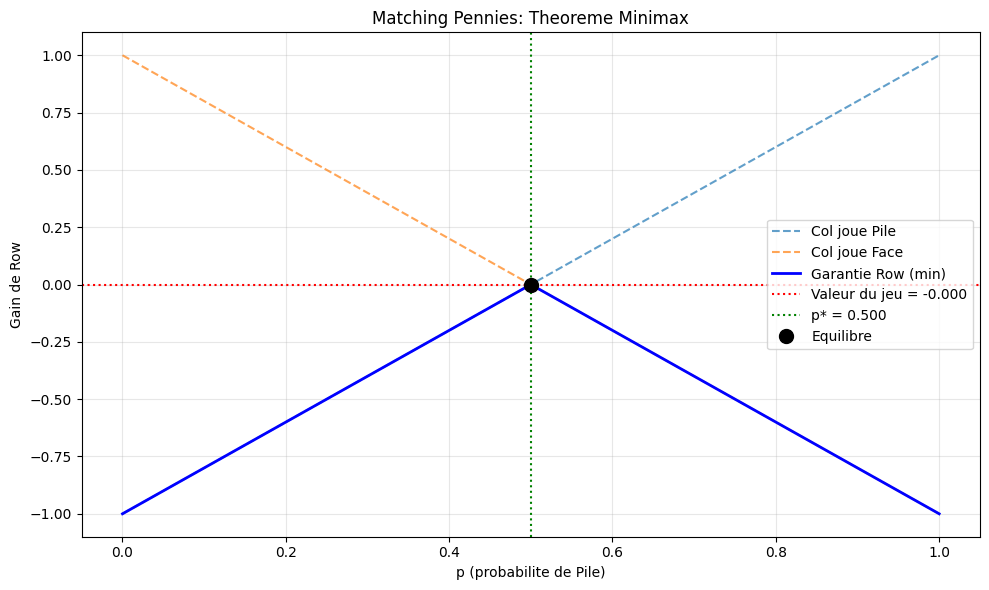

In [7]:
def visualize_minimax_2x2(game: ZeroSumGame):
    """
    Visualise le theoreme minimax pour un jeu 2x2.
    
    Montre:
    - Gain de Row en fonction de p (proba de R0) pour différents q (proba de C0)
    - L'enveloppe inferieure (maximin)
    - Le point d'equilibre
    """
    if game.A.shape != (2, 2):
        raise ValueError("Cette visualisation est pour les jeux 2x2")
    
    p_vals = np.linspace(0, 1, 100)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Gain de Row pour différentes stratégies pures de Col
    for j in range(2):
        gains = []
        for p in p_vals:
            sigma = np.array([p, 1-p])
            tau = np.zeros(2)
            tau[j] = 1
            gains.append(game.payoff(sigma, tau))
        ax.plot(p_vals, gains, '--', label=f'Col joue {game.col_labels[j]}', alpha=0.7)
    
    # Enveloppe inferieure (min sur les stratégies de Col)
    min_gains = []
    for p in p_vals:
        sigma = np.array([p, 1-p])
        min_g = min(game.payoff(sigma, np.array([1, 0])), 
                    game.payoff(sigma, np.array([0, 1])))
        min_gains.append(min_g)
    ax.plot(p_vals, min_gains, 'b-', linewidth=2, label='Garantie Row (min)')
    
    # Trouver l'equilibre
    sigma_opt, v = solve_minimax_lp(game)
    p_opt = sigma_opt[0]
    
    ax.axhline(y=v, color='r', linestyle=':', label=f'Valeur du jeu = {v:.3f}')
    ax.axvline(x=p_opt, color='g', linestyle=':', label=f'p* = {p_opt:.3f}')
    ax.plot(p_opt, v, 'ko', markersize=10, label='Equilibre')
    
    ax.set_xlabel(f'p (probabilite de {game.row_labels[0]})')
    ax.set_ylabel('Gain de Row')
    ax.set_title(f'{game.name}: Theoreme Minimax')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualiser Matching Pennies
visualize_minimax_2x2(mp)

### Interpretation : Visualisation du theoreme minimax

Le graphique illustre le coeur du theoreme minimax pour Matching Pennies :

**Lecture du graphique** :
- **Axe X** : probabilite $p$ que Row joue "Pile"
- **Lignes pointillees** : gain de Row si Col joue une stratégie pure
- **Ligne bleue** : garantie minimale de Row (enveloppe inferieure)

**Point d'equilibre** :
- A $p^* = 0.5$, les deux lignes pointillees se croisent
- C'est le point ou Row **maximise sa garantie minimale**
- La valeur du jeu $v = 0$ : le jeu est equitable

> **Intuition geometrique** : Row cherche le point le plus haut sur l'enveloppe inferieure. Ce point correspond exactement a l'intersection des droites - la ou Col est indifferent entre ses deux actions.

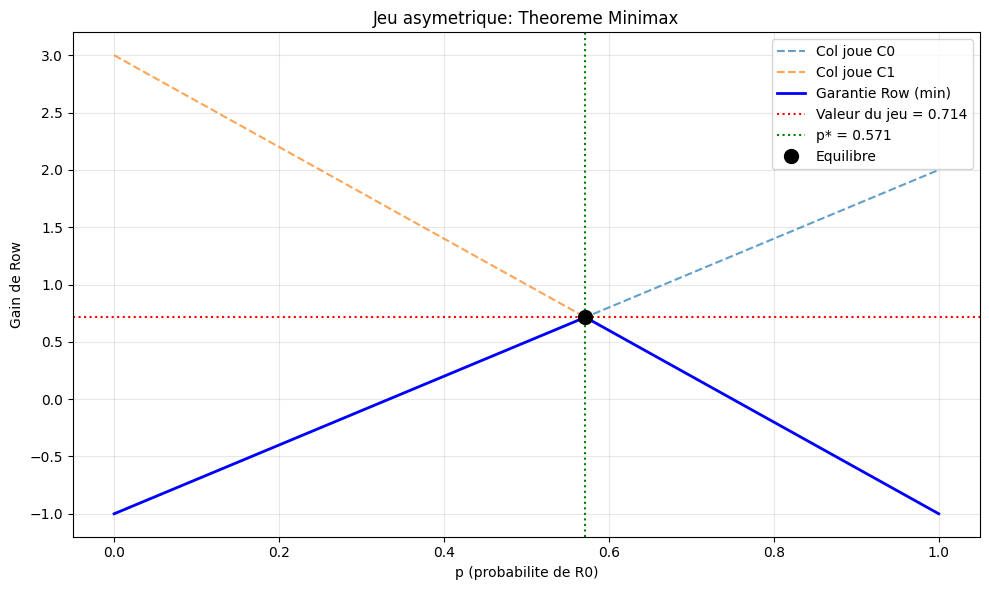

In [8]:
# Jeu asymetrique
asym_game = ZeroSumGame(
    A=[[2, -1],
       [-1, 3]],
    row_labels=['R0', 'R1'],
    col_labels=['C0', 'C1'],
    name="Jeu asymetrique"
)

visualize_minimax_2x2(asym_game)

## 5. Dualite en programmation lineaire

Le theoreme minimax est intimement lie a la **dualite LP**.

### Problème primal (Row maximise)

$$\begin{aligned}
\max & \quad v \\
\text{s.t.} & \quad \sum_i \sigma_i A_{ij} \geq v \quad \forall j \\
& \quad \sum_i \sigma_i = 1 \\
& \quad \sigma_i \geq 0
\end{aligned}$$

### Problème dual (Col minimise)

$$\begin{aligned}
\min & \quad w \\
\text{s.t.} & \quad \sum_j A_{ij} \tau_j \leq w \quad \forall i \\
& \quad \sum_j \tau_j = 1 \\
& \quad \tau_j \geq 0
\end{aligned}$$

Par dualite forte : $v^* = w^*$.

In [9]:
def verify_duality(game: ZeroSumGame):
    """Verifie la dualite LP pour le theoreme minimax."""
    print(f"\nVerification de la dualite pour: {game.name}")
    print("=" * 50)
    
    sigma_opt, v_primal = solve_minimax_lp(game)
    tau_opt, v_dual = solve_minimax_dual(game)
    
    print(f"\nProbleme primal (Row maximise):")
    print(f"  sigma* = {np.round(sigma_opt, 4)}")
    print(f"  v* = {v_primal:.6f}")
    
    print(f"\nProbleme dual (Col minimise):")
    print(f"  tau* = {np.round(tau_opt, 4)}")
    print(f"  w* = {v_dual:.6f}")
    
    print(f"\nDualite forte: v* = w* ? {abs(v_primal - v_dual) < 1e-6}")
    
    # Verification complementary slackness
    print(f"\nVerification des contraintes:")
    print(f"  Gains de Row pour chaque action Col:")
    gains_row = sigma_opt @ game.A
    for j, g in enumerate(gains_row):
        print(f"    Col joue {game.col_labels[j]}: {g:.4f} >= {v_primal:.4f} ? {g >= v_primal - 1e-6}")

verify_duality(rps)
verify_duality(mp)


Verification de la dualite pour: Pierre-Feuille-Ciseaux

Probleme primal (Row maximise):
  sigma* = [0.3333 0.3333 0.3333]
  v* = -0.000000

Probleme dual (Col minimise):
  tau* = [0.3333 0.3333 0.3333]
  w* = -0.000000

Dualite forte: v* = w* ? True

Verification des contraintes:
  Gains de Row pour chaque action Col:
    Col joue Pierre: 0.0000 >= -0.0000 ? True
    Col joue Feuille: 0.0000 >= -0.0000 ? True
    Col joue Ciseaux: -0.0000 >= -0.0000 ? True

Verification de la dualite pour: Matching Pennies

Probleme primal (Row maximise):
  sigma* = [0.5 0.5]
  v* = -0.000000

Probleme dual (Col minimise):
  tau* = [0.5 0.5]
  w* = -0.000000

Dualite forte: v* = w* ? True

Verification des contraintes:
  Gains de Row pour chaque action Col:
    Col joue Pile: 0.0000 >= -0.0000 ? True
    Col joue Face: 0.0000 >= -0.0000 ? True


## 6. Application : Colonel Blotto

Le jeu du **Colonel Blotto** est un jeu classique d'allocation de ressources.

### Règles
- Deux joueurs ont chacun $N$ soldats
- Ils les repartissent sur $K$ champs de bataille
- Celui qui a le plus de soldats sur un champ le gagne
- Objectif : gagner le plus de champs

In [10]:
from itertools import combinations_with_replacement

def generate_blotto_strategies(soldiers: int, battlefields: int) -> list:
    """
    Genere toutes les allocations possibles de soldats sur les champs.
    
    Returns:
        Liste de tuples (allocation) ou sum(allocation) = soldiers
    """
    stratégies = []
    
    def generate(remaining, fields_left, current):
        if fields_left == 1:
            stratégies.append(tuple(current + [remaining]))
            return
        
        for s in range(remaining + 1):
            generate(remaining - s, fields_left - 1, current + [s])
    
    generate(soldiers, battlefields, [])
    return stratégies

def blotto_payoff(alloc1: tuple, alloc2: tuple) -> int:
    """
    Calcule le gain du joueur 1 (nombre de champs gagnes - nombre perdu).
    """
    wins = sum(1 if a > b else 0 for a, b in zip(alloc1, alloc2))
    losses = sum(1 if a < b else 0 for a, b in zip(alloc1, alloc2))
    return wins - losses

def create_blotto_game(soldiers: int, battlefields: int) -> ZeroSumGame:
    """
    Créé la matrice du jeu Colonel Blotto.
    """
    stratégies = generate_blotto_strategies(soldiers, battlefields)
    n = len(stratégies)
    
    A = np.zeros((n, n))
    for i, s1 in enumerate(stratégies):
        for j, s2 in enumerate(stratégies):
            A[i, j] = blotto_payoff(s1, s2)
    
    labels = [str(s) for s in stratégies]
    return ZeroSumGame(A, labels, labels, f"Blotto({soldiers},{battlefields})")

# Petit exemple: 4 soldats, 3 champs
blotto_4_3 = create_blotto_game(4, 3)
print(f"Blotto(4 soldats, 3 champs)")
print(f"Nombre de stratégies: {blotto_4_3.m}")

# Resoudre
sigma_opt, v = solve_minimax_lp(blotto_4_3)

print(f"\nValeur du jeu: {v:.4f}")
print(f"\nStrategies jouees avec probabilite > 0.01:")
for i, p in enumerate(sigma_opt):
    if p > 0.01:
        print(f"  {blotto_4_3.row_labels[i]}: {p:.3f}")

Blotto(4 soldats, 3 champs)
Nombre de stratégies: 15

Valeur du jeu: -0.0000

Strategies jouees avec probabilite > 0.01:
  (0, 2, 2): 0.333
  (2, 0, 2): 0.333
  (2, 2, 0): 0.333


### Interpretation : Stratégie optimale du Colonel Blotto

Les résultats revelent une propriete remarquable du jeu Blotto :

**Observation cle** : Sur les 15 stratégies possibles, seules **3** sont jouees a l'equilibre, chacune avec probabilite 1/3 :
- `(0, 2, 2)` : abandonner un champ pour concentrer les forces
- `(2, 0, 2)` : même logique, champ central abandonne
- `(2, 2, 0)` : même logique, dernier champ abandonne

**Principe stratégique** : La stratégie `(2, 2, 0)` et ses permutations dominent car :
1. Elles garantissent de **gagner 2 champs sur 3** contre les repartitions uniformes comme `(1, 1, 2)`
2. Elles se **neutralisent mutuellement** (egalite contre elles-mêmes)

**Valeur du jeu = 0** : Le jeu est parfaitement equilibre - aucun joueur ne peut garantir un avantage.

> **Intuition militaire** : Il vaut mieux abandonner completement un front pour dominer les autres, plutot que de diluer ses forces uniformement. C'est le principe de la **concentration des forces**.

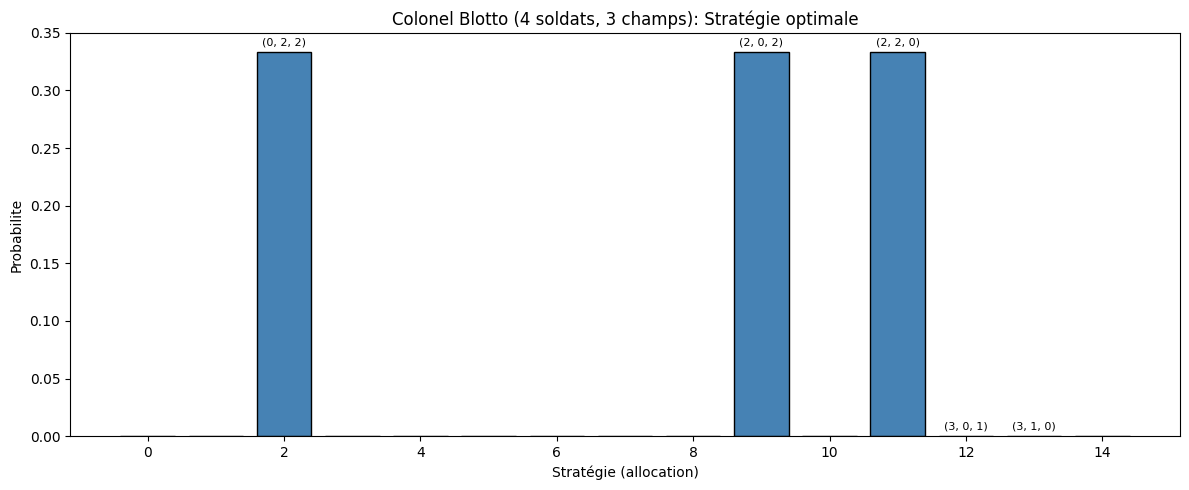

In [11]:
# Visualiser la distribution
fig, ax = plt.subplots(figsize=(12, 5))

stratégies = generate_blotto_strategies(4, 3)
x = range(len(stratégies))
ax.bar(x, sigma_opt, color='steelblue', edgecolor='black')

# Marquer les stratégies principales
top_idx = np.argsort(sigma_opt)[-5:]
for i in top_idx:
    ax.annotate(f"{stratégies[i]}", (i, sigma_opt[i]), 
                textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

ax.set_xlabel('Stratégie (allocation)')
ax.set_ylabel('Probabilite')
ax.set_title('Colonel Blotto (4 soldats, 3 champs): Stratégie optimale')

plt.tight_layout()
plt.show()

## 7. Resume

### Points cles

| Concept | Description |
|---------|-------------|
| **Somme nulle** | $u_1 + u_2 = 0$ pour tout profil |
| **Maximin** | Row maximise son pire cas |
| **Minimax** | Col minimise le meilleur cas de Row |
| **Theoreme minimax** | max min = min max en stratégies mixtes |
| **Valeur du jeu** | Gain de Row a l'equilibre |

### Algorithmes

| Méthode | Complexite | Description |
|---------|------------|-------------|
| Enumeration | $O(mn)$ | Point-selle en stratégies pures |
| LP | Polynomiale | Resolution exacte par simplexe/point interieur |
| Nashpy | Polynomiale | Bibliotheque specialisee |

### Applications

- Jeux de plateau (echecs, go) : evaluation de positions
- Securite : allocation de ressources defensives
- Sport : choix de stratégies
- Economie : competition a somme nulle

> **Lien avec la formalisation Lean** : Les structures de jeux a somme nulle (matrices de gains, equilibres de Nash) sont définies formellement dans les modules Lean du depot. Le module [`lean_game_defs/Basic.lean`](lean_game_defs/Basic.lean) définit les structures `NormalFormGame` et `Game2x2`, tandis que [`lean_game_defs/Nash.lean`](lean_game_defs/Nash.lean) formalise les meilleures reponses et l'equilibre de Nash en stratégies mixtes. Dans les jeux a somme nulle, la stratégie minimax de chaque joueur est identique a sa meilleure reponse a l'equilibre de Nash — le theoreme minimax de Von Neumann garantit que cet equilibre existe toujours.

## 8. Exercices

Les exercices suivants vous permettent de mettre en pratique les concepts de ce notebook :
stratégies maximin/minimax, resolution par programmation lineaire, et theoreme minimax.

### Exercice 1 : Colonel Blotto avec 5 soldats et 2 champs de bataille

**Objectif** : Resoudre le jeu Colonel Blotto avec 5 soldats et 2 champs de bataille, puis analyser la stratégie optimale.

**Contexte** : Nous avons vu comment resoudre Blotto(4,3) avec la fonction `create_blotto_game` et `solve_minimax_lp`. Vous devez appliquer la même méthode a une configuration différente.

**Étapes** :
1. Generer les stratégies avec `generate_blotto_strategies(5, 2)`
2. Créer le jeu avec `create_blotto_game(5, 2)`
3. Resoudre avec `solve_minimax_lp`
4. Afficher les stratégies jouees avec probabilite > 0.01

**Indice** : Avec 2 champs et 5 soldats, il y a 6 stratégies possibles. Observez quelles allocations sont privilegiees a l'equilibre.

In [12]:
# Exercice 1 : Colonel Blotto(5, 2)
# TODO etudiant : resoudre le jeu Colonel Blotto avec 5 soldats et 2 champs
# Étape 1 : generer les stratégies
# Étape 2 : créer le jeu avec create_blotto_game
# Étape 3 : resoudre avec solve_minimax_lp
# Étape 4 : afficher les stratégies jouees (probabilite > 0.01)
# Indice : les stratégies extremes (0,5) et (5,0) ne sont pas forcement dans la solution optimale

def exercice_1_blotto_5_2():
    """
    Resout Colonel Blotto(5 soldats, 2 champs).
    
    Returns:
        tuple: (sigma_opt, valeur_du_jeu, strategies_jouees)
    """
    return None  # TODO etudiant

print("Exercice a completer : Colonel Blotto(5,2)")

Exercice a completer : Colonel Blotto(5,2)


### Exercice 2 : Verification du theoreme minimax sur un jeu personnalise

**Objectif** : Construire un jeu a somme nulle 3x3 de votre choix, le resoudre par LP, et verifier le theoreme minimax.

**Contexte** : Le theoreme minimax garantit que pour toute matrice de gains a somme nulle, la valeur primale (Row maximise) egale la valeur duale (Col minimise). Vous allez verifier cette propriete sur un exemple que vous créez.

**Étapes** :
1. Construire une matrice 3x3 `A` quelconque (pas forcement antisymetrique)
2. Créer l'objet `ZeroSumGame` correspondant
3. Resoudre le primal avec `solve_minimax_lp` et le dual avec `solve_minimax_dual`
4. Verifier que `v_primal == v_dual` (dualite forte)

**Indice** : Essayez une matrice avec des coefficients entre -5 et 5. Utilisez `abs(v_primal - v_dual) < 1e-6` pour la comparaison.

In [13]:
# Exercice 2 : Verification du theoreme minimax sur un jeu 3x3 personnalise
# TODO etudiant : construire une matrice 3x3 a somme nulle et verifier minimax
# Étape 1 : définir la matrice A (3x3, valeurs entre -5 et 5 par exemple)
# Étape 2 : créer ZeroSumGame(A, ...)
# Étape 3 : appeler solve_minimax_lp et solve_minimax_dual
# Étape 4 : verifier que v_primal ≈ v_dual et afficher les stratégies optimales
# Indice : la fonction verify_duality(game) définie plus haut fait cette verification

def exercice_2_verifier_minimax():
    """
    Construit un jeu 3x3 et verifie le theoreme minimax.
    
    Returns:
        tuple: (v_primal, v_dual, dualite_forte_verifiee)
    """
    return None  # TODO etudiant

print("Exercice a completer : Verification du theoreme minimax")

Exercice a completer : Verification du theoreme minimax


### Exercice 3 : Detection d'un point-selle en stratégies pures

**Objectif** : Construire un jeu 3x3 a somme nulle possedant un point-selle (saddle point) en stratégies pures, puis le verifier.

**Contexte** : Un point-selle existe quand `maximin_pure == minimax_pure`, c'est-a-dire que la valeur maximin en stratégies pures egale la valeur minimax. Dans ce cas, l'equilibre de Nash est en stratégies pures et la valeur du jeu est exactement cette valeur commune.

**Étapes** :
1. Construire une matrice 3x3 `A` telle que `max(argmin(A, axis=1)) == min(argmax(A, axis=0))`
2. Créer le `ZeroSumGame`
3. Verifier avec `analyze_maximin_minimax` que le point-selle est detecte
4. Verifier avec `solve_minimax_lp` que la valeur LP correspond a la valeur du saddle point

**Indice** : Une matrice avec un élément qui est a la fois le minimum de sa ligne et le maximum de sa colonne possede un saddle point. Par exemple, si `A[1,1]` est le min de la ligne 1 et le max de la colonne 1, alors `(R1, C1)` est un saddle point.

In [14]:
# Exercice 3 : Construire un jeu 3x3 avec un point-selle en stratégies pures
# TODO etudiant : définir une matrice 3x3 avec un saddle point
# Étape 1 : construire A telle qu'un élément soit min de sa ligne ET max de sa colonne
# Étape 2 : créer ZeroSumGame et verifier avec analyze_maximin_minimax
# Étape 3 : verifier que la valeur LP correspond au saddle point
# Indice : commencez par choisir la valeur du saddle point (par exemple 2),
#   puis construisez la matrice autour pour que cette valeur soit bien le min de sa ligne
#   et le max de sa colonne

def exercice_3_point_selle():
    """
    Construit et verifie un jeu 3x3 avec un point-selle en stratégies pures.
    
    Returns:
        tuple: (matrice_A, position_saddle, valeur_saddle)
    """
    return None  # TODO etudiant

print("Exercice a completer : Detection d'un point-selle")

Exercice a completer : Detection d'un point-selle


## Resume et perspectives

Ce notebook a etudie les jeux a somme nulle et le theoreme minimax de Von Neumann (1928), pierre angulaire de la théorie des jeux. Nous avons défini les stratégies maximin (Row maximise son pire cas) et minimax (Col minimise le meilleur cas de Row), puis demontre que l'ecart entre ces deux valeurs se resout en stratégies mixtes. La resolution par programmation lineaire a confirme que les valeurs primale et duale coincident, illustrant la dualite forte LP. L'application au Colonel Blotto a revele un principe stratégique contre-intuitif : la concentration des forces sur un sous-ensemble de fronts surpasse la repartition uniforme, avec seulement 3 stratégies jouees a l'equilibre sur les 15 possibles.

Le theoreme minimax garantit l'existence d'une valeur unique du jeu pour toute matrice de gains, ce qui rend les jeux a somme nulle particulierement bien comportes. Cette propriete ne s'etend pas aux jeux généraux (a somme non nulle), pour lesquels il faut recourir au theoreme de Nash et a ses algorithmes de resolution (Support Enumeration, Lemke-Howson).

Le notebook suivant, [GameTheory-06-EvolutionTrust](GameTheory-06-EvolutionTrust.ipynb), quitte le cadre statique pour explorer la théorie des jeux evolutionnaire : comment la cooperation emerge-t-elle dans le Dilemme du Prisonnier Itere, et quelles stratégies survivent dans une population en evolution ?

***

**Notebook précédent**: [GameTheory-04-NashEquilibrium](GameTheory-04-NashEquilibrium.ipynb)  
**Notebook suivant**: [GameTheory-06-EvolutionTrust](GameTheory-06-EvolutionTrust.ipynb)